In [4]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving P2_small_bump.qasm to P2_small_bump.qasm
{'P2_small_bump.qasm': b'OPENQASM 2.0;\r\ninclude "qelib1.inc";\r\nqreg q[20];\r\nu3(2.517649475418522,0.03868362692032376,0.3626633825690021) q[0];\r\nu3(2.262488452016909,5.643983684668286,4.75724354180762) q[1];\r\nu3(0.5461740018545875,3.0773737381794537,3.4553319505289792) q[2];\r\nu3(1.2025090380841092,5.399714523819763,4.31014568854437) q[3];\r\ncz q[3],q[1];\r\nu3(1.3310573784728499,0.6137730650305335,-1.3490524600300189) q[1];\r\nu3(1.217541084924025,2.124707185625269,2.589089403896452) q[3];\r\nu3(0.8265001399156106,3.4848975445531476,0.11478786200328953) q[4];\r\nu3(0.49945328098514213,3.8278274366774214,1.2729354642622752) q[5];\r\ncz q[5],q[4];\r\nu3(3.090298565182128,1.2919504425269084,-0.6183196410724401) q[4];\r\nu3(0.8648701246531417,-2.8529127373955063,-0.8097505707963997) q[5];\r\nu3(1.4641071519102042,6.2145581032703605,2.6095341346861294) q[6];\r\nu3(2.605543074640037,2.0784718335179555,0.22181222469146722) q[7];\r\nu

In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install matplotlib
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=59a90f699a7505730b0073f978fc1f84f079f6fd9097758c625cd4c0d73ffb8b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [5]:
qc = QuantumCircuit.from_qasm_file("P2_small_bump.qasm")

qc.draw("mpl")

In [6]:
qc.measure_all()

In [8]:
simulator = AerSimulator()

result = simulator.run(qc, shots=500).result()

counts = result.get_counts()

In [9]:
peak_bitstring = max(counts, key=counts.get)

print("Peak bitstring:", peak_bitstring)
print("Counts:", counts[peak_bitstring])

Peak bitstring: 11000001000100011000
Counts: 97


In [10]:
plot_histogram(counts, figsize=(12,5))
plt.show()

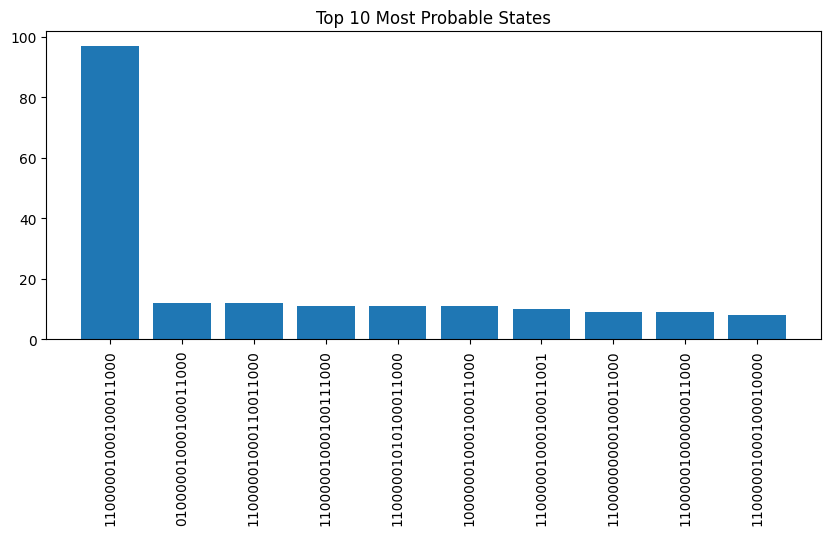

In [11]:
top_states = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(10,4))
plt.bar(top_states.keys(), top_states.values())
plt.xticks(rotation=90)
plt.title("Top 10 Most Probable States")
plt.show()